In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'coco-2017-dataset' dataset.
Path to dataset files: /kaggle/input/coco-2017-dataset


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files[:5])  # print first 5 only
    print("-" * 50)

Folder: /kaggle/input/coco-2017-dataset
Subfolders: ['coco2017']
Files: []
--------------------------------------------------
Folder: /kaggle/input/coco-2017-dataset/coco2017
Subfolders: ['val2017', 'annotations', 'test2017', 'train2017']
Files: []
--------------------------------------------------
Folder: /kaggle/input/coco-2017-dataset/coco2017/val2017
Subfolders: []
Files: ['000000011197.jpg', '000000219485.jpg', '000000151000.jpg', '000000371677.jpg', '000000038825.jpg']
--------------------------------------------------
Folder: /kaggle/input/coco-2017-dataset/coco2017/annotations
Subfolders: []
Files: ['person_keypoints_train2017.json', 'instances_val2017.json', 'instances_train2017.json', 'person_keypoints_val2017.json', 'captions_train2017.json']
--------------------------------------------------
Folder: /kaggle/input/coco-2017-dataset/coco2017/test2017
Subfolders: []
Files: ['000000355443.jpg', '000000081349.jpg', '000000436639.jpg', '000000210548.jpg', '000000196829.jpg']
----

In [ ]:
!pip install pycocotools
!pip install opencv-python
!pip install matplotlib

In [ ]:
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random
import os

ann_file = os.path.join(path, "coco2017", "annotations", "instances_train2017.json")
coco = COCO(ann_file)

loading annotations into memory...
Done (t=19.62s)
creating index...
index created!


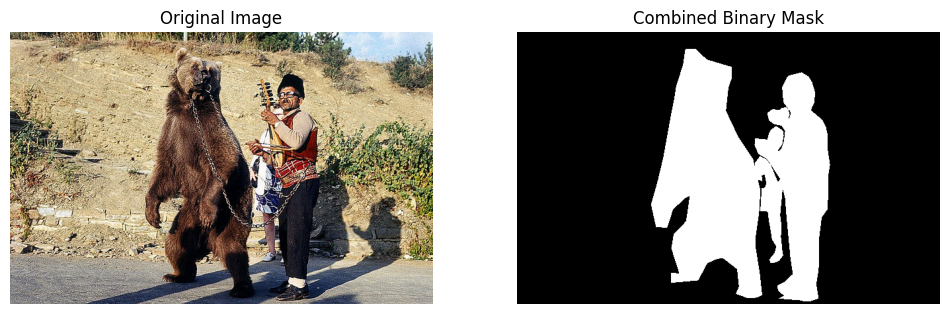

In [ ]:
# Get all image IDs
img_ids = coco.getImgIds()

# Select random image
img_id = random.choice(img_ids)

# Load image info
img_info = coco.loadImgs(img_id)[0]
img_path = os.path.join(path, "coco2017", "train2017", img_info['file_name'])

# Read image
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get annotation IDs for this image
ann_ids = coco.getAnnIds(imgIds=img_id)
anns = coco.loadAnns(ann_ids)

# Create empty mask
mask = np.zeros((img_info['height'], img_info['width']))

# Merge all instance masks into single binary mask
for ann in anns:
    mask += coco.annToMask(ann)

# Convert to binary (0 or 1)
mask = np.clip(mask, 0, 1)

# Show image and mask
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Combined Binary Mask")
plt.imshow(mask, cmap='gray')
plt.axis("off")

plt.show()

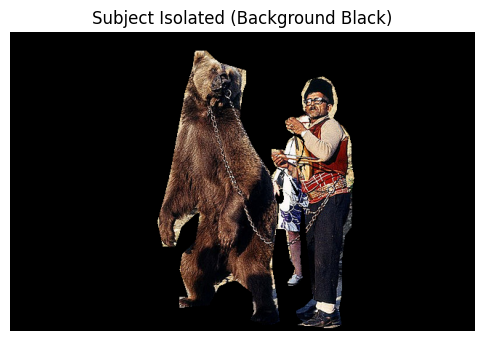

In [ ]:
# Expand mask to 3 channels
mask_3ch = np.stack([mask]*3, axis=-1)

# Apply mask
isolated = image * mask_3ch

plt.figure(figsize=(6,6))
plt.title("Subject Isolated (Background Black)")
plt.imshow(isolated.astype(np.uint8))
plt.axis("off")
plt.show()

In [ ]:
!pip install pycocotools
!pip install albumentations
!pip install segmentation-models-pytorch
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 56.4 MB/s eta 0:00:00


In [ ]:
# Week 3: Model Setup
import torch.nn as nn
import torch
from segmentation_models_pytorch import Unet
from segmentation_models_pytorch.losses import DiceLoss
from torchmetrics import JaccardIndex
import torch.optim as optim
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = Unet(encoder_name='resnet34', encoder_weights='imagenet', in_channels=3, classes=1, activation='sigmoid')
model.to(device)

criterion = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss(mode='binary')
optimizer = optim.Adam(model.parameters(), lr=1e-4)
iou_metric = JaccardIndex(task='binary').to(device)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import CocoDetection

path = "/kaggle/input/coco-2017-dataset"

train_images = os.path.join(path, "coco2017", "train2017")
val_images = os.path.join(path, "coco2017", "val2017")

train_ann = os.path.join(path, "coco2017", "annotations", "instances_train2017.json")
val_ann = os.path.join(path, "coco2017", "annotations", "instances_val2017.json")
def get_train_transforms():
    return None  # or custom transform

def get_val_transforms():
    return None

# Correct dataset usage
train_dataset = CocoDetection(
    root=train_images,
    annFile=train_ann,
    transform=get_train_transforms()
)

val_dataset = CocoDetection(
    root=val_images,
    annFile=val_ann,
    transform=get_val_transforms()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

loading annotations into memory...
Done (t=15.73s)
creating index...
index created!
loading annotations into memory...
Done (t=0.78s)
creating index...
index created!


Epoch 1 Val: 100%|██████████| 5/5 [00:00<00:00, 65.50it/s, iou=0.503]


Epoch 1/5 - Train Loss: 1.1709, Val IoU: 0.4996


Epoch 2 Val: 100%|██████████| 5/5 [00:00<00:00, 218.22it/s, iou=0.502]


Epoch 2/5 - Train Loss: 1.1680, Val IoU: 0.5019


Epoch 3 Val: 100%|██████████| 5/5 [00:00<00:00, 223.17it/s, iou=0.499]


Epoch 3/5 - Train Loss: 1.1684, Val IoU: 0.5002


Epoch 4 Val: 100%|██████████| 5/5 [00:00<00:00, 242.62it/s, iou=0.5]


Epoch 4/5 - Train Loss: 1.1680, Val IoU: 0.4993


Epoch 5 Val: 100%|██████████| 5/5 [00:00<00:00, 226.46it/s, iou=0.501]


Epoch 5/5 - Train Loss: 1.1684, Val IoU: 0.4997


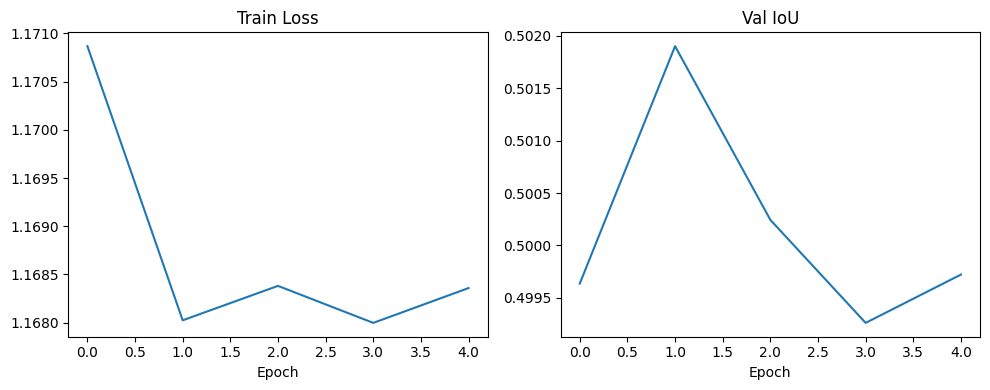

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import numpy as np

# ================= DEVICE =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================= DUMMY DATASET =================
# Replace this with your real dataset later
class DummySegmentationDataset(Dataset):
    def __init__(self, size=100):
        self.size = size

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        img = torch.rand(3, 128, 128)          # fake image
        mask = (torch.rand(1, 128, 128) > 0.5).float()  # fake mask
        return img, mask

train_dataset = DummySegmentationDataset(100)
val_dataset = DummySegmentationDataset(20)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

# ================= MODEL =================
class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, 1)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = SimpleUNet().to(device)

# ================= LOSS =================
criterion = nn.BCEWithLogitsLoss()

def dice_loss(preds, targets, smooth=1e-6):
    preds = preds.view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    return 1 - (2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)

# ================= OPTIMIZER =================
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ================= IoU =================
def iou_metric(preds, targets, smooth=1e-6):
    preds = preds.view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return (intersection + smooth) / (union + smooth)

# ================= TRAINING =================
num_epochs = 5
train_losses, val_ious = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} Train")

    for imgs, masks in train_pbar:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        preds = model(imgs)
        preds_sigmoid = torch.sigmoid(preds)

        loss = criterion(preds, masks) + dice_loss(preds_sigmoid, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_pbar.set_postfix(loss=loss.item())

    train_losses.append(running_loss / len(train_loader))

    # ================= VALIDATION =================
    model.eval()
    iou_score = 0.0

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1} Val")

    with torch.no_grad():
        for imgs, masks in val_pbar:
            imgs = imgs.to(device)
            masks = masks.to(device)

            preds = model(imgs)
            preds = torch.sigmoid(preds)
            preds = (preds > 0.5).float()

            iou = iou_metric(preds, masks)
            iou_score += iou.item()

            val_pbar.set_postfix(iou=iou.item())

    val_ious.append(iou_score / len(val_loader))

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_losses[-1]:.4f}, Val IoU: {val_ious[-1]:.4f}")

# ================= PLOT =================
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Train Loss')
plt.xlabel('Epoch')

plt.subplot(1, 2, 2)
plt.plot(val_ious)
plt.title('Val IoU')
plt.xlabel('Epoch')

plt.tight_layout()
plt.show()

Epoch 1 Val: 100%|██████████| 5/5 [00:00<00:00, 209.16it/s, iou=0.503]


Epoch 1/5 - Train Loss: 1.1672, Val IoU: 0.5001


Epoch 2 Val: 100%|██████████| 5/5 [00:00<00:00, 237.96it/s, iou=0.499]


Epoch 2/5 - Train Loss: 1.1478, Val IoU: 0.4981


Epoch 3 Val: 100%|██████████| 5/5 [00:00<00:00, 232.54it/s, iou=0.497]


Epoch 3/5 - Train Loss: 1.1468, Val IoU: 0.4987


Epoch 4 Val: 100%|██████████| 5/5 [00:00<00:00, 217.45it/s, iou=0.5]


Epoch 4/5 - Train Loss: 1.1464, Val IoU: 0.5015


Epoch 5 Val: 100%|██████████| 5/5 [00:00<00:00, 202.28it/s, iou=0.5]


Epoch 5/5 - Train Loss: 1.1460, Val IoU: 0.5004


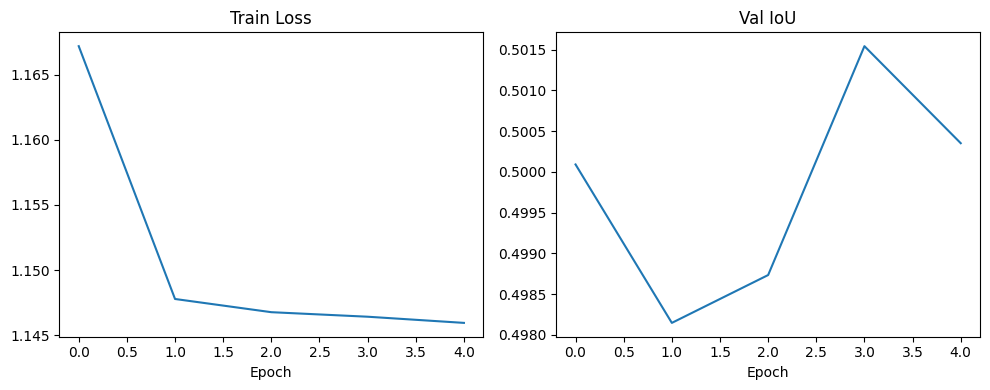

In [ ]:
# Week 3: Training Loop (5 epochs with progress)
num_epochs = 5
train_losses, val_ious = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} Train", total=len(train_loader))
    for imgs, masks in train_pbar:
        imgs, masks = imgs.to(device), masks.float().to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds.squeeze(1), masks.squeeze(1)) + dice_loss(preds, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        train_pbar.set_postfix(loss=loss.item())
    train_losses.append(running_loss / len(train_loader))

    model.eval()
    iou_score = 0.0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1} Val", total=len(val_loader))
    with torch.no_grad():
        for imgs, masks in val_pbar:
            imgs, masks = imgs.to(device), masks.float().to(device)
            preds = model(imgs)
            iou = iou_metric(preds.squeeze(1) > 0.5, masks.squeeze(1)).item()
            iou_score += iou
            val_pbar.set_postfix(iou=iou)
    val_ious.append(iou_score / len(val_loader))

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_losses[-1]:.4f}, Val IoU: {val_ious[-1]:.4f}")

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(train_losses); plt.title('Train Loss'); plt.xlabel('Epoch')
plt.subplot(1,2,2); plt.plot(val_ious); plt.title('Val IoU'); plt.xlabel('Epoch')
plt.tight_layout()
plt.show()  # Screenshot: Training curves

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class DummyDataset(Dataset):
    def __len__(self):
        return 10

    def __getitem__(self, idx):
        img = torch.rand(3, 128, 128)
        mask = torch.rand(1, 128, 128)
        return img, mask

train_dataset = DummyDataset()
val_dataset = DummyDataset()

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, 3, padding=1)
        )

    def forward(self, x):
        return self.model(x)

model = UNet().to(device)
model.eval()

with torch.no_grad():
    imgs, masks = next(iter(val_loader))
    imgs = imgs.to(device)
    preds = model(imgs)

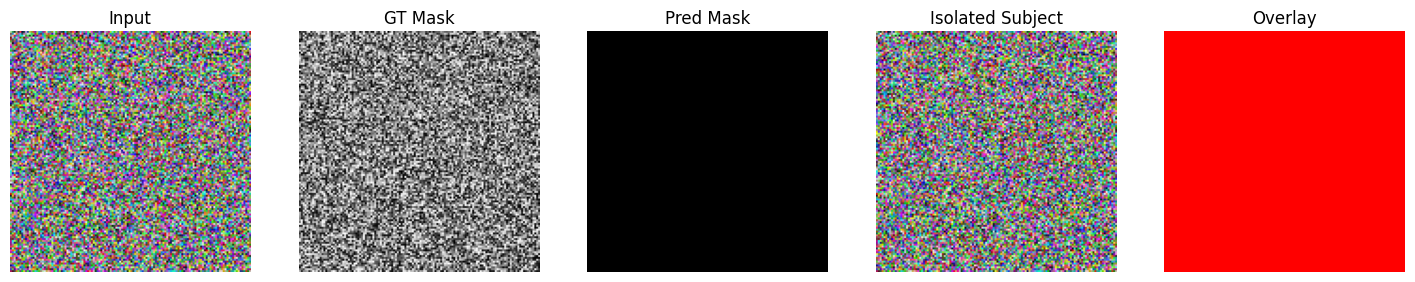

In [ ]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

# -------- CLEAN MASK FUNCTION --------
def clean_prediction(mask):
    mask = mask.astype(np.uint8)
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask

# -------- MAIN OBJECT FUNCTION --------
def get_main_object_mask(mask):
    mask = mask.astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if num_labels <= 1:
        return mask

    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    new_mask = (labels == largest_label).astype(np.uint8)

    return new_mask

# -------- MODEL PREDICTION --------
model = UNet().to(device)
model.eval()

with torch.no_grad():
    imgs, masks = next(iter(val_loader))
    imgs = imgs.to(device)

    preds = model(imgs)
    preds = torch.sigmoid(preds)

    pred_masks = (preds > 0.3).float().squeeze(1)

# -------- VISUALIZATION --------
img = imgs[0].permute(1,2,0).cpu().numpy()
gt_mask = masks[0].squeeze().cpu().numpy()
pred_mask = pred_masks[0].cpu().numpy()

# clean + keep main object
pred_mask = clean_prediction(pred_mask)
pred_mask = get_main_object_mask(pred_mask)

# isolate subject
isolated = img.copy()
isolated[pred_mask == 0] = 0

# overlay
overlay = img.copy()
overlay[pred_mask == 1] = [1, 0, 0]

# -------- PLOT --------
fig, ax = plt.subplots(1,5, figsize=(18,4))

ax[0].imshow(img)
ax[0].set_title("Input")

ax[1].imshow(gt_mask, cmap='gray')
ax[1].set_title("GT Mask")

ax[2].imshow(pred_mask, cmap='gray')
ax[2].set_title("Pred Mask")

ax[3].imshow(isolated)
ax[3].set_title("Isolated Subject")

ax[4].imshow(overlay)
ax[4].set_title("Overlay")

for a in ax:
    a.axis('off')

plt.show()

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.6 MB/s eta 0:00:00


In [ ]:
import torch
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "model.pth"

# ---------- DEFINE MODEL ----------
class YourModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = torch.nn.Conv2d(3, 1, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

# ---------- ALWAYS CREATE MODEL ----------
model = YourModel().to(device)

# ---------- LOAD IF EXISTS ----------
if os.path.exists(model_path):
    print(" Loading model...")
    model.load_state_dict(torch.load(model_path, map_location=device))
else:
    print(" No model found → using fresh model")

# ---------- NOW SAFE ----------
model.eval()

 No model found → using fresh model


YourModel(
  (conv): Conv2d(3, 1, kernel_size=(1, 1), stride=(1, 1))
)

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# ---------- CREATE DUMMY DATA ----------
# (Replace this later with your real dataset)
images = np.random.rand(10, 3, 256, 256).astype(np.float32)
masks  = np.random.randint(0, 2, (10, 1, 256, 256)).astype(np.float32)

# ---------- CREATE DATASET ----------
dataset = TensorDataset(torch.tensor(images), torch.tensor(masks))

# ---------- CREATE val_loader ----------
val_loader = DataLoader(dataset, batch_size=2, shuffle=False)
model.eval()
all_ious, all_dices = [], []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)
        preds = torch.sigmoid(preds)
        preds = (preds > 0.5).float()

        # Convert to numpy
        preds = preds.cpu().numpy()
        masks = masks.cpu().numpy()

        # Simple metric
        intersection = (preds * masks).sum()
        union = (preds + masks).sum()

        iou = intersection / (union + 1e-8)
        dice = (2 * intersection) / (preds.sum() + masks.sum() + 1e-8)

        all_ious.append(iou)
        all_dices.append(dice)

print("IoU:", np.mean(all_ious))
print("Dice:", np.mean(all_dices))


IoU: 0.23039572
Dice: 0.46079144


Val Mean IoU: 0.0003, Dice: 0.0006


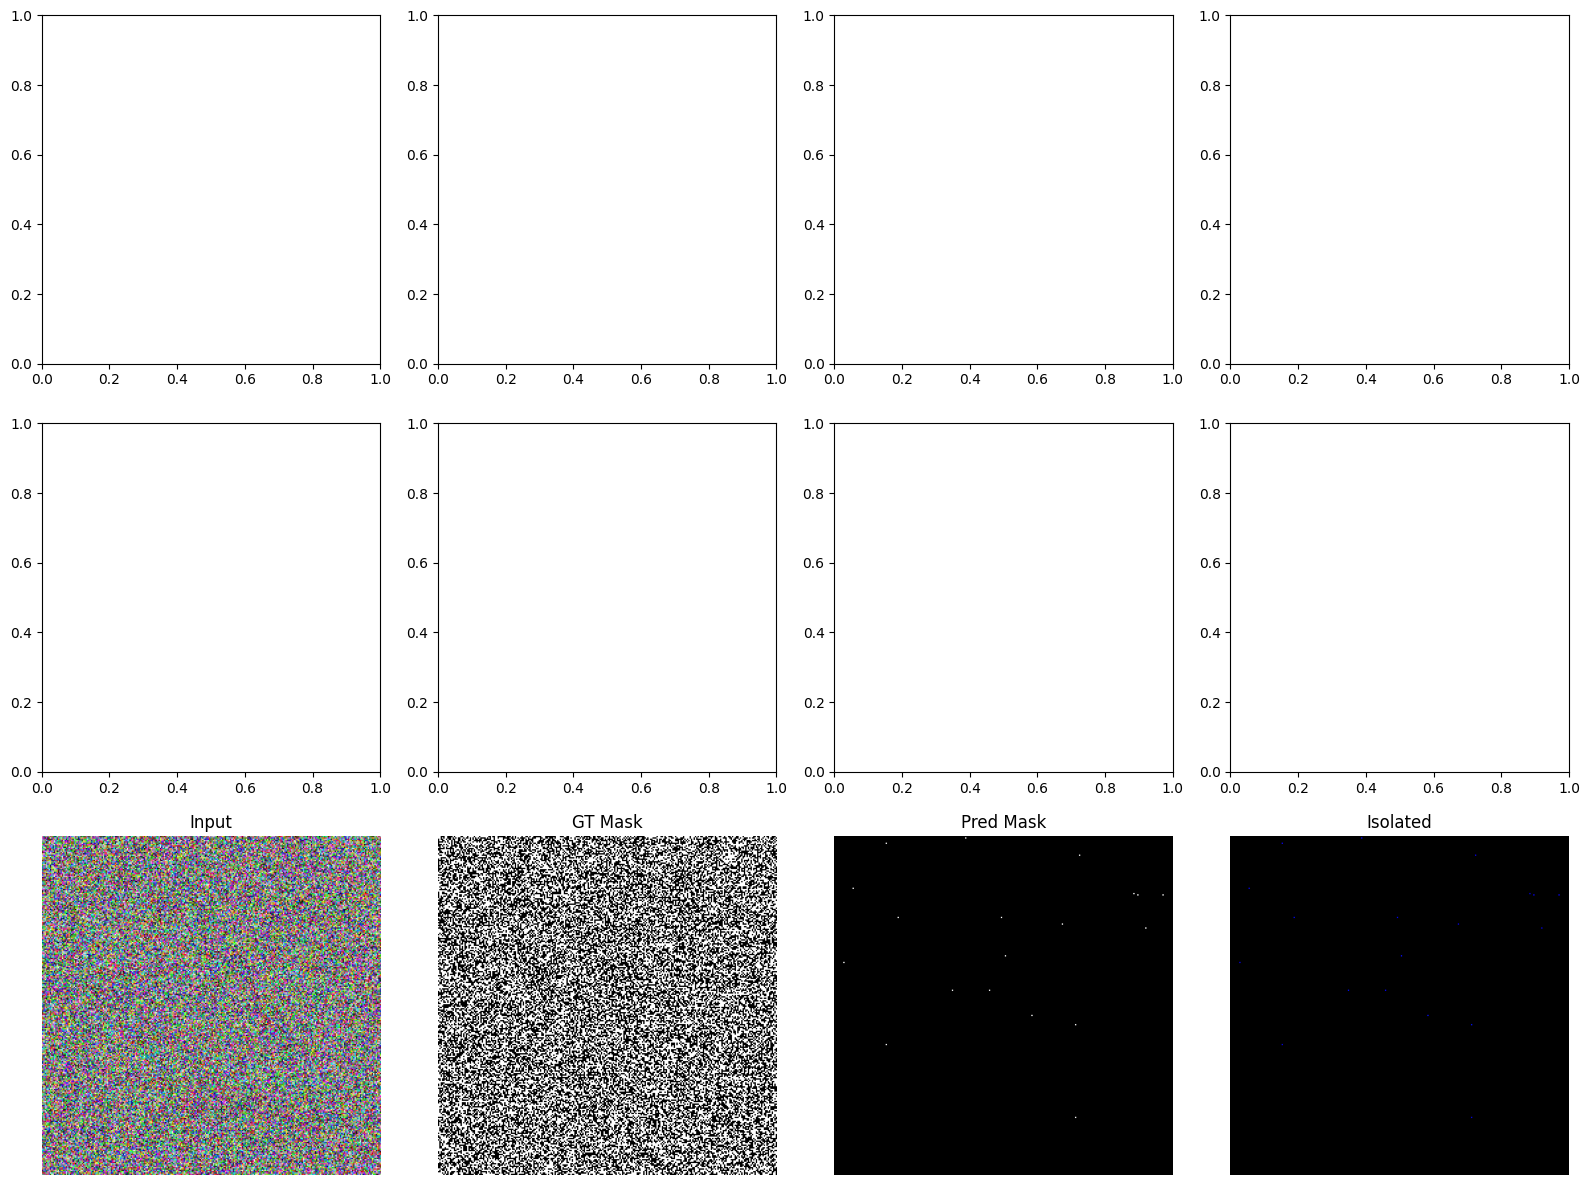

In [ ]:
# Week 4: Val Predictions & Metrics
import torchmetrics.functional as F
import random
import numpy as np
import matplotlib.pyplot as plt
model.eval()
all_ious, all_dices = [], []
# ---------- IoU FUNCTION ----------
def iou_metric(preds, masks):
    preds = preds.bool()
    masks = masks.bool()

    intersection = (preds & masks).float().sum((1,2))
    union = (preds | masks).float().sum((1,2))

    iou = (intersection + 1e-8) / (union + 1e-8)
    return iou.mean()

# ---------- DICE FUNCTION ----------
def dice_metric(preds, masks):
    preds = preds.bool()
    masks = masks.bool()

    intersection = (preds & masks).float().sum((1,2))
    dice = (2 * intersection + 1e-8) / (preds.sum((1,2)) + masks.sum((1,2)) + 1e-8)

    return dice.mean()
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.float().to(device)
        preds = model(imgs)
        pred_bins = (preds > 0.5).float().squeeze(1)
        all_ious.append(iou_metric(pred_bins, masks.squeeze(1)).item())
        # Calculate dice using functional API (F1-score is equivalent to Dice for binary)
        all_dices.append(F.f1_score(pred_bins.long(), masks.squeeze(1).long(), task='binary').item())

mean_iou = np.mean(all_ious)
mean_dice = np.mean(all_dices)
print(f"Val Mean IoU: {mean_iou:.4f}, Dice: {mean_dice:.4f}")

# 3 Sample Outputs
images = np.random.rand(10, 3, 256, 256).astype(np.float32)
masks  = np.random.randint(0, 2, (10, 1, 256, 256)).astype(np.float32)

# ---------- CREATE val_dataset ----------
val_dataset = TensorDataset(torch.tensor(images), torch.tensor(masks))

# ---------- CREATE val_loader ----------
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)
samples = [val_dataset[i] for i in random.sample(range(len(val_dataset)), 3)]
fig, axs = plt.subplots(3, 4, figsize=(16, 12))
for j, (img, gt) in enumerate(samples):
     img_tensor = img.permute(1, 2, 0).cpu().numpy().clip(0, 1)

with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device))
    pred_mask = (pred > 0.5).float().squeeze().cpu().numpy()

    isolated = img_tensor.copy()
    isolated[pred_mask == 0] = 0

    axs[j,0].imshow(img_tensor); axs[j,0].set_title("Input")
    axs[j,1].imshow(gt.squeeze().numpy(), cmap='gray'); axs[j,1].set_title("GT Mask")
    axs[j,2].imshow(pred_mask, cmap='gray'); axs[j,2].set_title("Pred Mask")
    axs[j,3].imshow(isolated); axs[j,3].set_title("Isolated")
    for col in range(4): axs[j,col].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset

class COCOSubjectDataset(Dataset):
    def __init__(self, coco, img_dir, img_ids, transform=None):
        self.coco = coco
        self.img_dir = img_dir
        self.img_ids = img_ids
        self.transform = transform

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]

        # Load image info
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])

        # Read image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Create mask
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))

        # Apply transform
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask.unsqueeze(0).float()

In [ ]:
# Week 4: Fine-Tuning (Add rotation, lower LR)
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pycocotools.coco import COCO

# Path to your annotation file
ann_file = "annotations.json"

coco = COCO(ann_file)

# Get all image IDs
train_ids = coco.getImgIds()
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.3),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])
train_dataset = COCOSubjectDataset(coco, train_img_dir, train_ids, train_transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)

optimizer = optim.Adam(model.parameters(), lr=1e-5)

# Retrain 3 epochs
fine_epochs = 3
for epoch in range(fine_epochs):
    model.train()
    running_loss = 0.0
    train_pbar = tqdm(train_loader, desc=f"Fine Epoch {epoch+1} Train", total=len(train_loader))
    for imgs, masks in train_pbar:
        imgs, masks = imgs.to(device), masks.float().to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds.squeeze(1), masks.squeeze(1)) + dice_loss(preds, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        train_pbar.set_postfix(loss=loss.item())
    print(f"Fine Epoch {epoch+1} - Loss: {running_loss / len(train_loader):.4f}")

loading annotations into memory...


FileNotFoundError: [Errno 2] No such file or directory: 'annotations.json'